**Prueba super rapida y sencilla de scipy para dendogramas**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [13]:
books = [
    {"title": "Dark Crown", "category": "Fantasy", "description": "dark magic kingdom war betrayal prophecy"},
    {"title": "Magic Academy", "category": "Fantasy", "description": "young wizards school mystery magic secrets danger"},
    {"title": "Dragon Realm", "category": "Fantasy", "description": "dragons kingdom quest prophecy battle adventure"},

    {"title": "Love in Paris", "category": "Romance", "description": "romance paris love emotional hope relationship"},
    {"title": "Summer Letters", "category": "Romance", "description": "friendship love healing lighthearted romance summer"},
    {"title": "Broken Hearts", "category": "Romance", "description": "loss healing emotional drama second chances romance"},

    {"title": "Atomic Habits 2", "category": "SelfHelp", "description": "habits productivity routines growth practical improvement"},
    {"title": "Deep Focus", "category": "SelfHelp", "description": "focus discipline concentration work efficiency practical"},
    {"title": "Mind Reset", "category": "SelfHelp", "description": "mindset goals motivation success self improvement"},

    {"title": "Murder Alley", "category": "Thriller", "description": "crime murder detective suspense mystery danger"},
    {"title": "Silent Witness", "category": "Thriller", "description": "investigation psychological suspense witness hidden truth"},
    {"title": "Night Evidence", "category": "Thriller", "description": "forensic clues suspects dark crime twists"},
]

df = pd.DataFrame(books)
df["text"] = df["title"] + " " + df["category"] + " " + df["description"]
df

,title,category,description,text
0,Dark Crown,Fantasy,dark magic kingdom war betrayal prophecy,Dark Crown Fantasy dark magic kingdom war betr...
1,Magic Academy,Fantasy,young wizards school mystery magic secrets danger,Magic Academy Fantasy young wizards school mys...
2,Dragon Realm,Fantasy,dragons kingdom quest prophecy battle adventure,Dragon Realm Fantasy dragons kingdom quest pro...
3,Love in Paris,Romance,romance paris love emotional hope relationship,Love in Paris Romance romance paris love emoti...
4,Summer Letters,Romance,friendship love healing lighthearted romance s...,Summer Letters Romance friendship love healing...
5,Broken Hearts,Romance,loss healing emotional drama second chances ro...,Broken Hearts Romance loss healing emotional d...
6,Atomic Habits 2,SelfHelp,habits productivity routines growth practical ...,Atomic Habits 2 SelfHelp habits productivity r...
7,Deep Focus,SelfHelp,focus discipline concentration work efficiency...,Deep Focus SelfHelp focus discipline concentra...
8,Mind Reset,SelfHelp,mindset goals motivation success self improvement,Mind Reset SelfHelp mindset goals motivation s...
9,Murder Alley,Thriller,crime murder detective suspense mystery danger,Murder Alley Thriller crime murder detective s...


In [14]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["text"]).toarray()

# Distancias entre libros
D = pdist(X, metric="cosine")

# Árbol jerárquico completo
Z = linkage(D, method="average")

print("Shape de X:", X.shape)
print("Shape de Z:", Z.shape)

Shape de X: (12, 78)
Shape de Z: (11, 4)


In [15]:
def threshold_for_k(Z, k):
    """
    Regresa un threshold para visualizar un corte que produzca K clusters.
    """
    n = Z.shape[0] + 1

    if k <= 1:
        return Z[-1, 2] + 1e-6  # arriba de todo: 1 cluster

    if k >= n:
        return 0.0  # abajo de todo: cada hoja sola

    # Distancia del merge anterior y siguiente
    d_low = Z[n - k - 1, 2]
    d_high = Z[n - k, 2]

    return (d_low + d_high) / 2

In [16]:
def plot_dendrogram_for_k(Z, labels, k):
    t = threshold_for_k(Z, k)

    plt.figure(figsize=(14, 6))
    dendrogram(
        Z,
        labels=labels,
        leaf_rotation=60,
        leaf_font_size=10,
        color_threshold=t
    )
    plt.axhline(y=t, color="black", linestyle="--", linewidth=1)
    plt.title(f"Dendrograma con corte para K = {k}")
    plt.xlabel("Libros")
    plt.ylabel("Distancia")
    plt.tight_layout()
    plt.show()

    clusters = fcluster(Z, t=k, criterion="maxclust")
    out = pd.DataFrame({
        "title": labels,
        "cluster": clusters
    }).sort_values("cluster").reset_index(drop=True)

    print(f"Asignación de clusters para K = {k}")
    display(out)

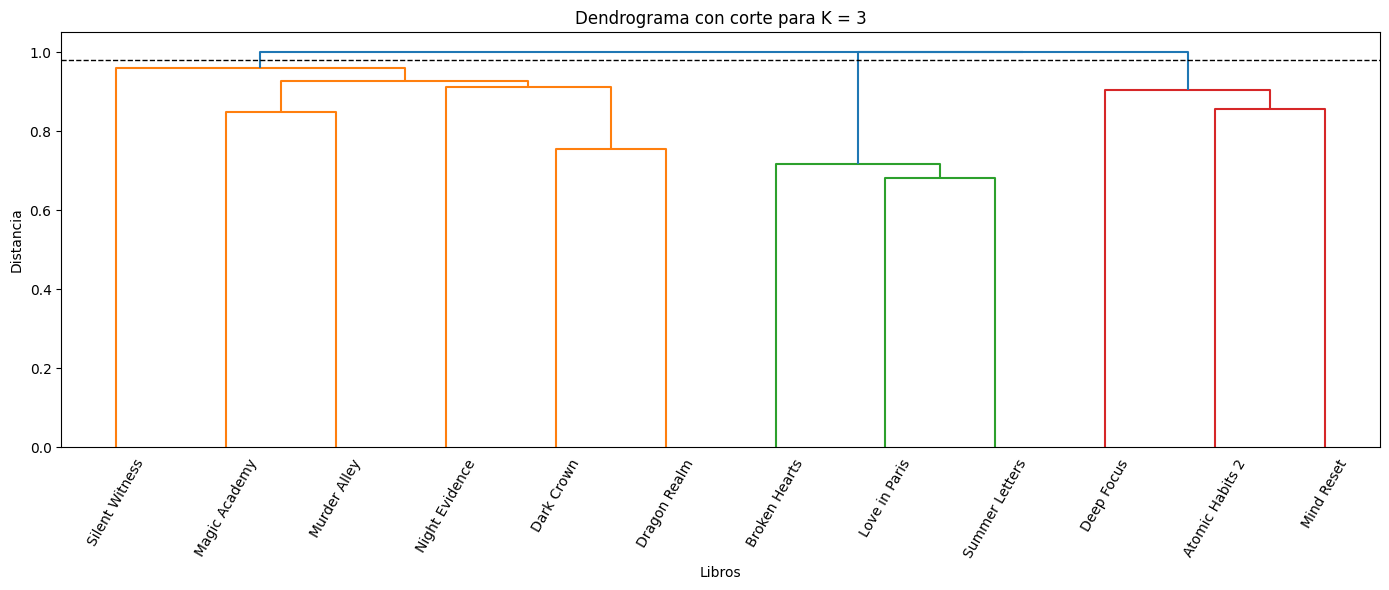

Asignación de clusters para K = 3


,title,cluster
0,Dark Crown,1
1,Magic Academy,1
2,Dragon Realm,1
3,Murder Alley,1
4,Silent Witness,1
5,Night Evidence,1
6,Summer Letters,2
7,Love in Paris,2
8,Broken Hearts,2
9,Atomic Habits 2,3


In [17]:
plot_dendrogram_for_k(Z, df["title"].tolist(), k=3)

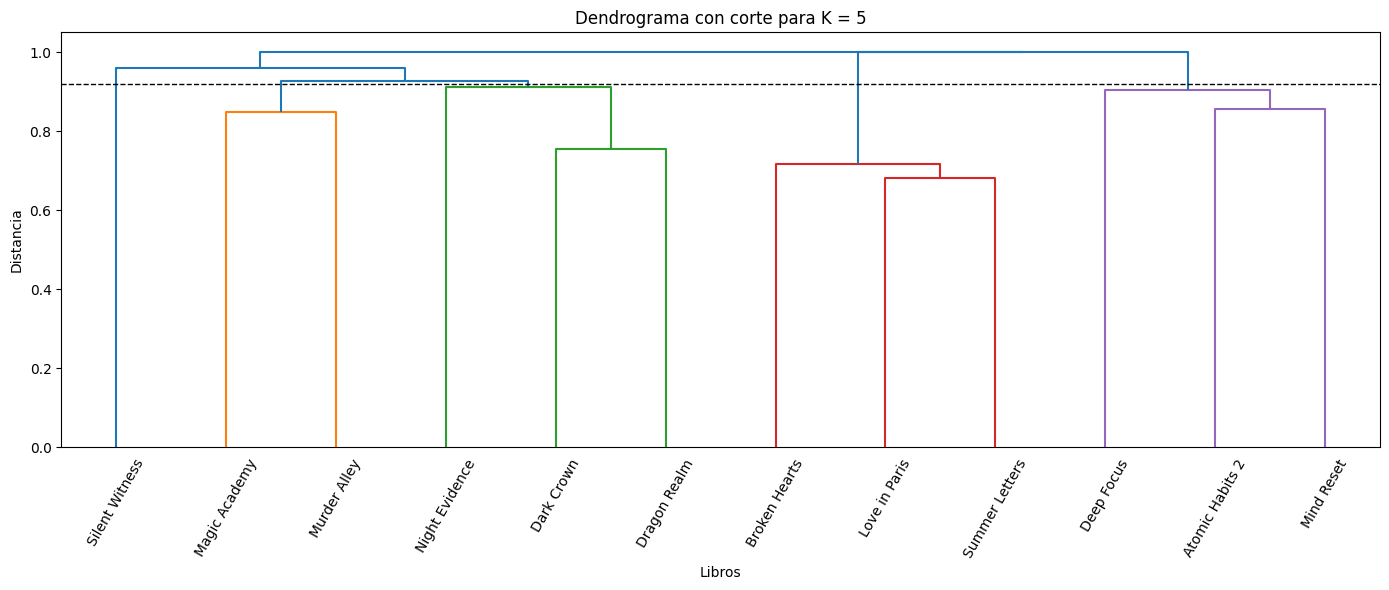

Asignación de clusters para K = 5


,title,cluster
0,Magic Academy,1
1,Murder Alley,1
2,Dragon Realm,2
3,Dark Crown,2
4,Night Evidence,2
5,Silent Witness,3
6,Summer Letters,4
7,Love in Paris,4
8,Broken Hearts,4
9,Atomic Habits 2,5


In [18]:
plot_dendrogram_for_k(Z, df["title"].tolist(), k=5)

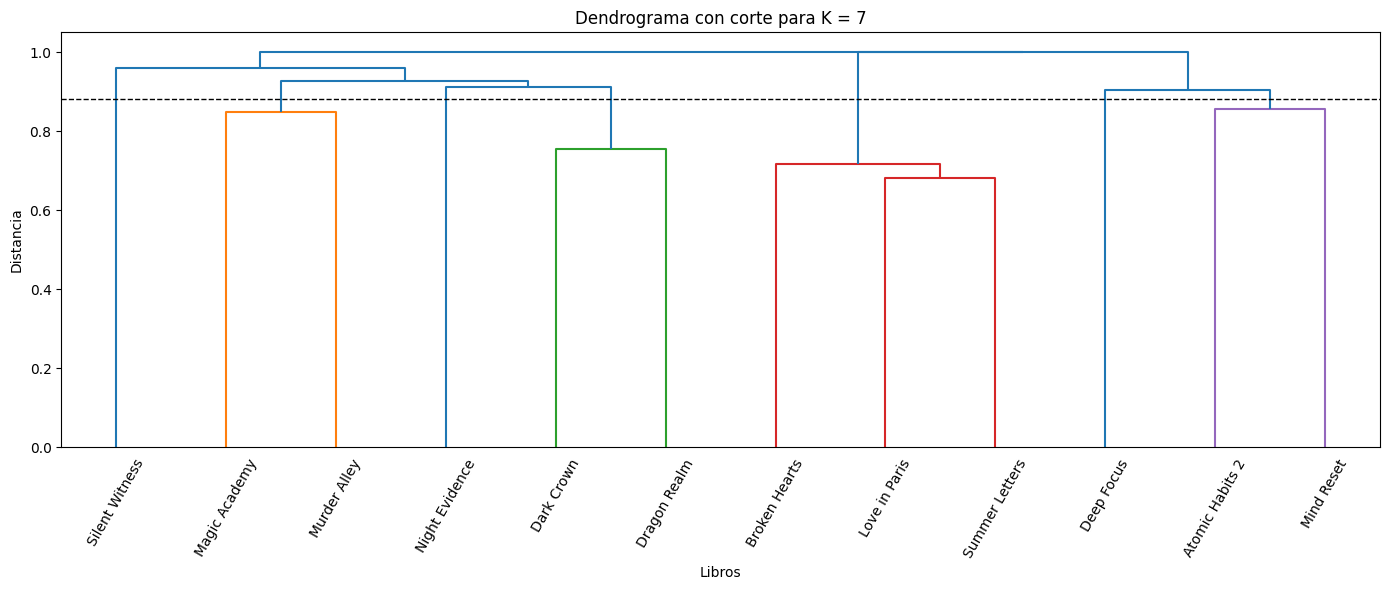

Asignación de clusters para K = 7


,title,cluster
0,Magic Academy,1
1,Murder Alley,1
2,Dragon Realm,2
3,Dark Crown,2
4,Night Evidence,3
5,Silent Witness,4
6,Summer Letters,5
7,Love in Paris,5
8,Broken Hearts,5
9,Atomic Habits 2,6


In [19]:
plot_dendrogram_for_k(Z, df["title"].tolist(), k=7)